# Baseline Comparisons

Runs all four baseline sampling strategies on the BirdSet **HSN, POW, UHH** datasets and **ATFBL** dataset with a shared
configuration to establish baseline performance and inform a reasonable `MAX_BUDGET`.

Strategies compared:
- `random` — random sampling (challenge baseline)
- `margin_multilabel` — uncertainty-based margin sampling
- `sklearn_coreset` — diversity-based coreset selection
- `sklearn_typiclust` — typicality clustering

**AULC** (Area Under the Learning Curve) for mAP (macro) is the primary metric:


In [22]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import time

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

In [23]:
# ---------------------------------------------------------------------------
# Shared baseline configuration — same across all datasets
# ---------------------------------------------------------------------------

# AL loop parameters
N_CYCLES            = 15
EPOCHS_PER_CYCLE    = 10
BATCH_SIZE          = 32
N_SAMPLES_PER_CYCLE = 50    # fixed per cycle (no scheduler)

# Number of independent full-run repeats (each creates a fresh ActiveLearner
# with random model initialisation).  Mean and SD are computed across these runs.
# NOTE: the `repeats` parameter inside ActiveLearner is set to 1 below — that
# internal mechanism resets to the *same* model state and does not constitute
# independent initialisation.
N_REPEATS = 5

# Optional budget cap — None means no cap (explore full budget)
MAX_BUDGET: int | None = None

# Warm-up samples before the AL loop (None = cold start)
PRETRAIN_SAMPLES: int | None = None

# Baseline strategies to compare
STRATEGIES = [
    "random",
    "margin_multilabel",
    "sklearn_coreset",
    "sklearn_typiclust",
]

print(f"Cycles            : {N_CYCLES}")
print(f"Samples per cycle : {N_SAMPLES_PER_CYCLE}")
print(f"Epochs per cycle  : {EPOCHS_PER_CYCLE}")
print(f"Outer repeats     : {N_REPEATS}  (independent runs, fresh model init each time)")
print(f"Max budget        : {MAX_BUDGET or 'none'}")
print(f"Strategies        : {STRATEGIES}")

Cycles            : 15
Samples per cycle : 50
Epochs per cycle  : 10
Outer repeats     : 5  (independent runs, fresh model init each time)
Max budget        : none
Strategies        : ['random', 'margin_multilabel', 'sklearn_coreset', 'sklearn_typiclust']


## Step 1: Dataset paths

Set paths for the HSN dataset. The same paths are used for all four strategies.

In [24]:
MODEL_NAME     = "perch_v2"
DATASET_NAME   = "ATBFL_BASEAL"

EMBEDDINGS_DIR = PROJECT_ROOT / DATASET_NAME / "embeddings" / MODEL_NAME
LABELS_PATH    = PROJECT_ROOT / DATASET_NAME / "labels.csv"

print(f"Embeddings : {EMBEDDINGS_DIR}")
print(f"Labels     : {LABELS_PATH}")
print(f"Dataset    : {DATASET_NAME}  |  Model: {MODEL_NAME}")

Embeddings : c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\ATBFL_BASEAL\embeddings\perch_v2
Labels     : c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\ATBFL_BASEAL\labels.csv
Dataset    : ATBFL_BASEAL  |  Model: perch_v2


## Step 2: Run all baseline strategies

Each strategy runs the full AL loop with the shared configuration.
Results are collected in `results` for comparison and exported to `results/baselines/`.

In [25]:
# results[strategy] = list of training_history (one list per outer repeat)
# all_learners[strategy] = last ActiveLearner instance (for config/export metadata)
results     = {}
all_learners = {}

OUTPUT_DIR = PROJECT_ROOT / "results" / "baselines"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_dataset_info_printed = False

for strategy in STRATEGIES:
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy}")
    print(f"{'='*60}")

    strategy_histories = []  # one training_history list per repeat

    for rep in range(N_REPEATS):
        print(f"\n  -- Repeat {rep + 1}/{N_REPEATS} --")

        # Fresh ActiveLearner each repeat → random model re-initialisation.
        # repeats=1 disables the internal SD mechanism (handled by this outer loop).
        learner = ActiveLearner(
            embeddings_dir=EMBEDDINGS_DIR,
            annotations_path=LABELS_PATH,
            model_name=MODEL_NAME,
            dataset_name=DATASET_NAME,
            learning_rate=0.001,
            sampling_strategy=strategy,
            verbose=False,
            pretrain_samples=PRETRAIN_SAMPLES,
        )

        if not _dataset_info_printed:
            state = learner.get_state()
            print(f"\n  Dataset: {DATASET_NAME}  |  Total: {state['n_labeled'] + state['n_unlabeled']}  |  Classes: {state['num_classes']}\n")
            _dataset_info_printed = True

        print(f"  {'Cycle':>5}  {'Labelled':>8}  {'mAP':>8}  {'AULC':>8}")
        print(f"  {'-'*38}")

        for cycle in range(N_CYCLES):
            start = time.time()
            n_to_sample = N_SAMPLES_PER_CYCLE
            if MAX_BUDGET is not None:
                remaining = MAX_BUDGET - len(learner.labeled_indices)
                if remaining <= 0:
                    print(f"  Budget of {MAX_BUDGET} reached — stopping.")
                    break
                n_to_sample = min(n_to_sample, remaining)

            selected = learner.sample(n_samples=n_to_sample)
            learner.add_samples(selected)
            metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)
            print(f"  {cycle + 1:>5}  {metrics['n_labeled']:>8}  {metrics['mAP']:>8.4f}  {metrics['aulc_mAP']:>8.4f} {time.time() - start:>8.4f}")

        strategy_histories.append(learner.training_history)
        all_learners[strategy] = learner  # keep last for metadata

    results[strategy] = strategy_histories

    # Summary across repeats
    final_mAPs  = [h[-1]['mAP']       for h in strategy_histories]
    final_aulcs = [h[-1]['aulc_mAP']  for h in strategy_histories]
    print(f"\n  Final mAP : {np.mean(final_mAPs):.4f} ± {np.std(final_mAPs):.4f}")
    print(f"  Final AULC: {np.mean(final_aulcs):.4f} ± {np.std(final_aulcs):.4f}")


Strategy: random

  -- Repeat 1/5 --

  Dataset: ATBFL_BASEAL  |  Total: 12506  |  Classes: 8

  Cycle  Labelled       mAP      AULC
  --------------------------------------
      1        50    0.3898    0.1949   0.9790
      2       100    0.4470    0.3067   1.2130
      3       150    0.4677    0.3569   1.2770
      4       200    0.4858    0.3869   1.5900
      5       250    0.4962    0.4077   1.6350
      6       300    0.5030    0.4230   1.9020
      7       350    0.5106    0.4350   2.0470
      8       400    0.5038    0.4440   2.3070
      9       450    0.5117    0.4511   2.8250
     10       500    0.5156    0.4573   3.2000
     11       550    0.5211    0.4629   3.3790
     12       600    0.5160    0.4675   3.5270
     13       650    0.5163    0.4713   3.8150
     14       700    0.5100    0.4743   4.0300
     15       750    0.5128    0.4767   4.3770

  -- Repeat 2/5 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------
      1        50    

core.utils.sampling - WARNING - sklearn_coreset: no labeled samples, falling back to random


      1        50    0.4188    0.2094   0.9440
      2       100    0.4636    0.3253   7.6030
      3       150    0.4736    0.3731   7.7800
      4       200    0.4865    0.3998   8.1220
      5       250    0.4802    0.4165   8.2770
      6       300    0.4884    0.4278   8.6000
      7       350    0.4897    0.4366   8.7210
      8       400    0.4937    0.4435   9.2470
      9       450    0.5004    0.4494   9.9050
     10       500    0.4867    0.4538  10.2950
     11       550    0.4922    0.4571  10.6800
     12       600    0.4876    0.4598  11.4420
     13       650    0.4991    0.4624  11.2120
     14       700    0.4939    0.4648  11.3440
     15       750    0.5025    0.4670  11.9310

  -- Repeat 2/5 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------


core.utils.sampling - WARNING - sklearn_coreset: no labeled samples, falling back to random


      1        50    0.4162    0.2081   1.0289
      2       100    0.4594    0.3229   8.1280
      3       150    0.4655    0.3694   8.1420
      4       200    0.4720    0.3943   8.4880
      5       250    0.4644    0.4090   9.0430
      6       300    0.4746    0.4191   8.7180
      7       350    0.4855    0.4278   9.0340
      8       400    0.4926    0.4355   9.2290
      9       450    0.4930    0.4418  11.1990
     10       500    0.5002    0.4473  11.3850
     11       550    0.5051    0.4524  13.1720
     12       600    0.5016    0.4566  15.2783
     13       650    0.5032    0.4601  13.3136
     14       700    0.5142    0.4636  12.9810
     15       750    0.5103    0.4668  12.2040

  -- Repeat 3/5 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------


...

      1        50    0.4109    0.2054   0.9790
      2       100    0.4647    0.3216   8.0420
      3       150    0.4772    0.3714   8.2310
      4       200    0.4808    0.3983   8.2950
      5       250    0.4695    0.4137   8.4770
      6       300    0.4707    0.4231   9.1880
      7       350    0.4740    0.4301   9.5080
      8       400    0.4799    0.4360   9.1480
      9       450    0.4808    0.4409   9.8220
     10       500    0.4833    0.4450  11.6260
     11       550    0.4850    0.4486  13.4080
     12       600    0.4874    0.4517  13.5800
     13       650    0.4905    0.4546  14.2540
     14       700    0.4964    0.4573  14.3770
     15       750    0.4938    0.4599  15.0970

  -- Repeat 4/5 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------


core.utils.sampling - WARNING - sklearn_coreset: no labeled samples, falling back to random


      1        50    0.4094    0.2047   1.4420
      2       100    0.4401    0.3148   9.6140
      3       150    0.4505    0.3583   9.9390
      4       200    0.4638    0.3830  10.1740
      5       250    0.4602    0.3988  10.3170
      6       300    0.4693    0.4098  11.0190
      7       350    0.4696    0.4183  11.4130
      8       400    0.4801    0.4254  11.8040
      9       450    0.4871    0.4318  12.4980
     10       500    0.4920    0.4376  12.9980
     11       550    0.4951    0.4427  17.5080
     12       600    0.4961    0.4471  15.6080
     13       650    0.4872    0.4505  15.7550
     14       700    0.4856    0.4531  16.0720
     15       750    0.4913    0.4554  17.0130

  -- Repeat 5/5 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------


core.utils.sampling - WARNING - sklearn_coreset: no labeled samples, falling back to random


      1        50    0.3531    0.1765   1.6209
      2       100    0.4102    0.2791  10.4841
      3       150    0.4380    0.3274  10.9551
      4       200    0.4542    0.3571  11.2704
      5       250    0.4496    0.3761  10.5110
      6       300    0.4580    0.3890   8.4990
      7       350    0.4584    0.3989   7.6360
      8       400    0.4703    0.4071   7.8710
      9       450    0.4767    0.4145   9.0200
     10       500    0.4797    0.4208   8.8510
     11       550    0.4738    0.4259   8.9090
     12       600    0.4835    0.4303   9.1090
     13       650    0.4867    0.4345   9.8490
     14       700    0.4881    0.4383   9.7430
     15       750    0.4833    0.4415   9.9500

  Final mAP : 0.4962 ± 0.0093
  Final AULC: 0.4581 ± 0.0094

Strategy: sklearn_typiclust

  -- Repeat 1/5 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------
      1        50    0.4011    0.2006  19.3670
      2       100    0.4382    0.3101  20.2980
      3     

## Step 3: Compare learning curves across strategies

In [26]:
def aggregate_histories(histories):
    """
    Aggregate a list of training histories (one per outer repeat) into
    per-cycle mean and SD.

    Args:
        histories: list of training_history lists, each of length N_CYCLES.

    Returns:
        List of dicts — one entry per cycle — with keys:
            cycle, n_labeled,
            mAP_mean, mAP_sd,
            aulc_mAP_mean, aulc_mAP_sd,
            annotation_cost,
            sampling_time_s_mean, sampling_time_s_sd
    """
    n_cycles = min(len(h) for h in histories)
    agg = []
    for c in range(n_cycles):
        entries = [h[c] for h in histories]
        mAPs  = np.array([e['mAP']         for e in entries])
        aulcs = np.array([e['aulc_mAP']    for e in entries])
        stimes = np.array([e.get('sampling_time_s', 0.0) for e in entries])
        agg.append({
            'cycle':              c + 1,
            'n_labeled':          entries[0]['n_labeled'],   # identical across repeats
            'mAP_mean':           float(np.mean(mAPs)),
            'mAP_sd':             float(np.std(mAPs)),
            'aulc_mAP_mean':      float(np.mean(aulcs)),
            'aulc_mAP_sd':        float(np.std(aulcs)),
            'annotation_cost':    entries[0].get('annotation_cost', 0),
            'sampling_time_s_mean': float(np.mean(stimes)),
            'sampling_time_s_sd':   float(np.std(stimes)),
        })
    return agg

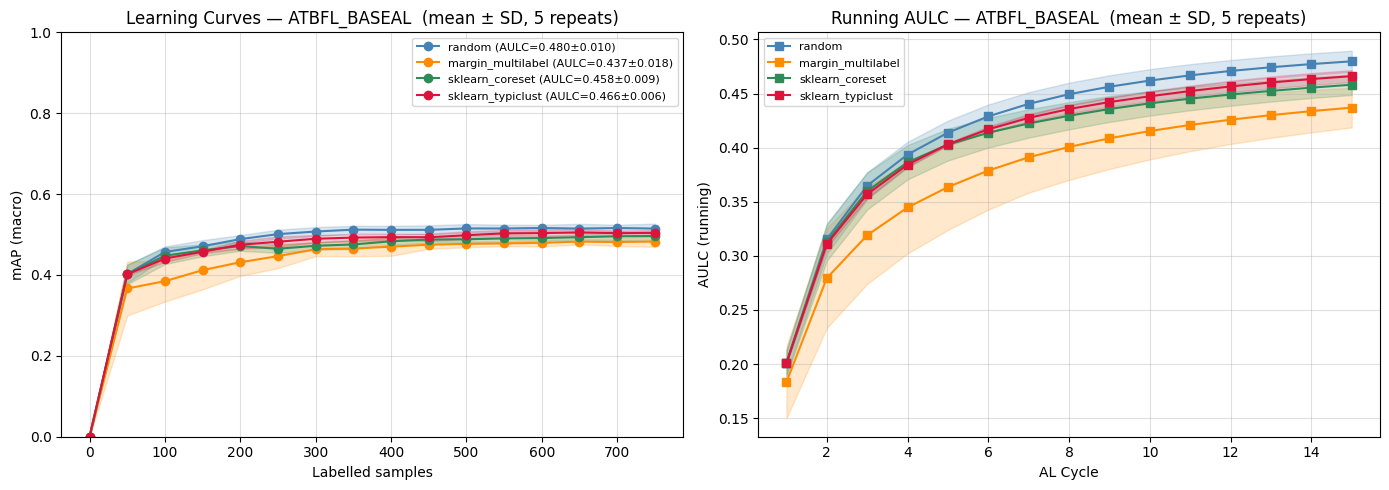


Final results — ATBFL_BASEAL  (5 outer repeats)
Strategy                             mAP (mean±SD)      AULC (mean±SD)
------------------------------------------------------------------------
random                          0.5147 ±0.0122  0.4798 ±0.0098
margin_multilabel               0.4827 ±0.0132  0.4370 ±0.0183
sklearn_coreset                 0.4962 ±0.0093  0.4581 ±0.0094
sklearn_typiclust               0.5042 ±0.0068  0.4661 ±0.0055


In [27]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (strategy, histories), color in zip(results.items(), colors):
    agg = aggregate_histories(histories)

    n_labeled   = np.array([0]   + [a['n_labeled']    for a in agg])
    mAP_means   = np.array([0.0] + [a['mAP_mean']     for a in agg])
    mAP_sds     = np.array([0.0] + [a['mAP_sd']       for a in agg])
    aulc_means  = np.array([a['aulc_mAP_mean'] for a in agg])
    aulc_sds    = np.array([a['aulc_mAP_sd']  for a in agg])
    cycles      = np.arange(1, len(aulc_means) + 1)

    final_aulc_mean = agg[-1]['aulc_mAP_mean']
    final_aulc_sd   = agg[-1]['aulc_mAP_sd']
    label = f"{strategy} (AULC={final_aulc_mean:.3f}±{final_aulc_sd:.3f})"

    # mAP learning curve
    axes[0].plot(n_labeled, mAP_means, marker='o', color=color, label=label)
    axes[0].fill_between(n_labeled,
                         mAP_means - mAP_sds,
                         mAP_means + mAP_sds,
                         alpha=0.2, color=color)

    # Running AULC curve
    axes[1].plot(cycles, aulc_means, marker='s', color=color, label=strategy)
    axes[1].fill_between(cycles,
                         aulc_means - aulc_sds,
                         aulc_means + aulc_sds,
                         alpha=0.2, color=color)

axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curves — {DATASET_NAME}  (mean ± SD, {N_REPEATS} repeats)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title(f'Running AULC — {DATASET_NAME}  (mean ± SD, {N_REPEATS} repeats)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal results — {DATASET_NAME}  ({N_REPEATS} outer repeats)")
print(f"{'Strategy':<30}  {'mAP (mean±SD)':>18}  {'AULC (mean±SD)':>18}")
print("-" * 72)
for strategy, histories in results.items():
    agg = aggregate_histories(histories)
    final = agg[-1]
    print(f"{strategy:<30}  {final['mAP_mean']:>6.4f} ±{final['mAP_sd']:>6.4f}  "
          f"{final['aulc_mAP_mean']:>6.4f} ±{final['aulc_mAP_sd']:>6.4f}")

## Step 4: Exported files

Each strategy's results are written to `results/baselines/` as a YAML file.
Inspect these to determine an appropriate `MAX_BUDGET` and confirm baseline performance.

In [28]:
import yaml
from datetime import datetime

_BASELINE_EPOCHS     = 10
_BASELINE_BATCH_SIZE = 32


def export_aggregated(strategy, histories, learner, output_path, max_budget=None):
    """
    Export aggregated (mean ± SD across outer repeats) results as a YAML file.

    The per-cycle learning curve contains mAP and AULC mean/SD.
    Supplementary fields include total annotation cost and sampling wall-time
    (mean ± SD across repeats) and the standard computational cost ratio.
    """
    agg = aggregate_histories(histories)
    model_parameters = int(sum(p.numel() for p in learner.model.parameters()))
    n_cycles = len(agg)
    epochs_per_cycle = EPOCHS_PER_CYCLE

    # Per-cycle rows
    learning_curve = []
    for a in agg:
        learning_curve.append({
            'cycle':                 a['cycle'],
            'n_labeled':             a['n_labeled'],
            'mAP_mean':              round(a['mAP_mean'],          6),
            'mAP_sd':                round(a['mAP_sd'],            6),
            'aulc_mAP_mean':         round(a['aulc_mAP_mean'],     6),
            'aulc_mAP_sd':           round(a['aulc_mAP_sd'],       6),
            'annotation_cost':       a['annotation_cost'],
            'sampling_time_s_mean':  round(a['sampling_time_s_mean'], 6),
            'sampling_time_s_sd':    round(a['sampling_time_s_sd'],   6),
        })

    # Aggregate annotation cost and sampling time across repeats
    total_ann_costs = [
        sum(h[c].get('annotation_cost', 0) for c in range(n_cycles))
        for h in histories
    ]
    total_stimes = [
        sum(h[c].get('sampling_time_s', 0.0) for c in range(n_cycles))
        for h in histories
    ]

    # Computational cost
    baseline_n_cycles = max_budget // _BASELINE_BATCH_SIZE if max_budget else n_cycles
    cost_method   = model_parameters * epochs_per_cycle * n_cycles
    baseline_cost = model_parameters * _BASELINE_EPOCHS * baseline_n_cycles
    relative_cost = round(cost_method / baseline_cost, 4) if baseline_cost > 0 else None

    submission = {
        'submission_timestamp':   datetime.now().isoformat(timespec='seconds'),
        'author_lastname':        'baseline',
        'institute_abbreviation': 'BASEAL',
        'sampling_strategy':      strategy,
        'dataset':                DATASET_NAME,
        'model':                  MODEL_NAME,
        'config': {
            'learning_rate':      learner.learning_rate,
            'model_parameters':   model_parameters,
            'n_outer_repeats':    N_REPEATS,
            'pretrain_samples':   learner.pretrain_samples,
        },
        'learning_curve': learning_curve,
        'supplementary': {
            'n_cycles':                       n_cycles,
            'n_outer_repeats':                N_REPEATS,
            'total_annotation_cost_mean':     round(float(np.mean(total_ann_costs)), 2),
            'total_annotation_cost_sd':       round(float(np.std(total_ann_costs)),  2),
            'total_sampling_time_s_mean':     round(float(np.mean(total_stimes)),    6),
            'total_sampling_time_s_sd':       round(float(np.std(total_stimes)),     6),
            'computational_cost': {
                'model_parameters':   model_parameters,
                'epochs_per_cycle':   epochs_per_cycle,
                'n_cycles':           n_cycles,
                'cost_method':        cost_method,
                'baseline_n_cycles':  baseline_n_cycles,
                'baseline_cost':      baseline_cost,
                'relative_cost':      relative_cost,
            },
        },
    }

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        yaml.dump(submission, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
    print(f"  Saved: {Path(output_path).name}")


print(f"Files saved to: {PROJECT_ROOT / 'results' / 'baselines'}\n")
for strategy in STRATEGIES:
    safe_name = DATASET_NAME.replace('/', '_')
    output_file = OUTPUT_DIR / f"{strategy}_{safe_name}.yaml"
    export_aggregated(
        strategy=strategy,
        histories=results[strategy],
        learner=all_learners[strategy],
        output_path=str(output_file),
        max_budget=MAX_BUDGET,
    )

Files saved to: c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\results\baselines

  Saved: random_ATBFL_BASEAL.yaml
  Saved: margin_multilabel_ATBFL_BASEAL.yaml
  Saved: sklearn_coreset_ATBFL_BASEAL.yaml
  Saved: sklearn_typiclust_ATBFL_BASEAL.yaml


## Notes

- `MAX_BUDGET = None` — the loop runs for exactly `N_CYCLES × N_SAMPLES_PER_CYCLE` samples with no cap.
  Set `MAX_BUDGET` to a specific value once an appropriate budget has been determined from these results.
- All four strategies use the same `learning_rate`, `epochs`, and `batch_size` to ensure fair comparison.
- The YAML exports in `results/baselines/` contain the full learning curve and can be used to set
  `MAX_BUDGET` in the challenge participant notebooks.